# Exploratory Analysis — Multi‑Asset ETF Portfolio Optimization & Backtesting

This notebook provides a complete exploratory analysis of a diversified ETF portfolio:

- Multi‑asset ETF universe (equities, bonds, credit, gold, REITs)
- Monthly returns and descriptive statistics
- Correlation structure and diversification insights
- Maximum Sharpe Ratio portfolio optimization
- Efficient Frontier simulation
- All‑Weather (Ray Dalio) portfolio backtest
- Rolling window backtest (dynamic re‑optimization)
- Cross‑sectional momentum strategy
- Sensitivity analysis of portfolio weights
- Full performance comparison across strategies

This notebook is designed as a realistic quantitative research workflow for ETF allocation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from src.data_loader import load_data
from src.returns import compute_monthly_returns, annualized_return, annualized_volatility
from src.optimization import maximize_sharpe
from src.efficient_frontier import generate_random_portfolios
from src.rolling_backtest import rolling_backtest
from src.momentum import momentum_strategy, apply_strategy
from src.sensitivity import sensitivity_analysis
from src.backtest import backtest_portfolio
from src.visualization import plot_efficient_frontier, plot_performance

plt.style.use("seaborn-v0_8")


## 1. ETF Universe

We build a realistic multi‑asset ETF universe including:

- US equities (broad market, value, growth)
- International developed markets
- Emerging markets
- Long‑term Treasuries
- Investment grade & high yield credit
- Gold
- Real estate (REITs)


In [2]:
tickers = {
    "US_Total": "VTI",
    "US_Value": "VTV",
    "US_Growth": "VUG",
    "World_ExUS": "VEA",
    "EM_Equity": "VWO",
    "LT_Treasury": "TLT",
    "IG_Credit": "LQD",
    "HY_Credit": "HYG",
    "Gold": "GLD",
    "REITs": "VNQ",
}


In [3]:
prices = load_data(tickers, start_date="2006-01-01")
prices.tail()


[*********************100%***********************]  10 of 10 completed


,US_Total,US_Value,US_Growth,World_ExUS,EM_Equity,LT_Treasury,IG_Credit,HY_Credit,Gold,REITs
Date,,,,,,,,,,
2026-04-17,445.929993,80.650002,110.040001,87.070000,69.629997,96.680000,350.529999,204.240005,82.320000,59.180000
2026-04-20,442.089996,80.580002,110.029999,87.050003,69.330002,97.029999,350.209991,204.250000,82.096664,58.910000
2026-04-21,429.570007,80.370003,109.610001,86.570000,67.820000,95.309998,347.839996,202.970001,81.500000,58.200001
2026-04-22,435.260010,80.500000,109.820000,86.739998,68.349998,94.519997,351.220001,202.869995,83.019997,58.759998
2026-04-23,434.609985,80.519997,109.904999,86.970001,68.334999,95.334999,351.480011,204.099899,82.729698,58.355000


In [4]:
returns = compute_monthly_returns(prices)
returns.tail()


c:\Finance\Quant-projects\Quant_projects\ETF_Portfolio_optimization\src\returns.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = prices.resample("M").last()


,US_Total,US_Value,US_Growth,World_ExUS,EM_Equity,LT_Treasury,IG_Credit,HY_Credit,Gold,REITs
Date,,,,,,,,,,
2025-12-31,0.021501,0.004914,-0.007402,-0.026946,0.031289,-0.022616,-0.000265,0.007841,-0.005068,0.009473
2026-01-31,0.115765,0.006059,0.003443,-0.000344,0.057994,0.025770,0.015685,0.044845,-0.013018,0.049180
2026-02-28,0.083606,-0.000013,0.013686,0.045296,0.059238,0.052455,-0.005299,0.036907,-0.043894,0.028456
2026-03-31,-0.117109,-0.009582,-0.020946,-0.043221,-0.090085,-0.065221,-0.051344,-0.049327,-0.052558,-0.072256
2026-04-30,0.009990,0.016832,0.012461,0.007212,0.064290,0.072137,0.091304,0.039475,0.127886,0.076636


## 2. Descriptive Statistics & Correlations


In [ ]:
# Cell 8 — Annualized Stats
ann_ret = annualized_return(returns)
ann_vol = annualized_volatility(returns)

summary = pd.DataFrame({
    "Annualized_Return": ann_ret,
    "Annualized_Volatility": ann_vol,
})
summary


,Annualized_Return,Annualized_Volatility
US_Total,0.100577,0.170539
US_Value,0.045535,0.099110
US_Growth,0.041182,0.080340
World_ExUS,0.029721,0.137271
EM_Equity,0.045687,0.174266
LT_Treasury,0.061460,0.224963
IG_Credit,0.102421,0.157460
HY_Credit,0.087517,0.152120
Gold,0.119296,0.170728
REITs,0.053483,0.205695


In [ ]:
#Cell 9 — Correlation Matrix
corr = returns.corr()
corr


,US_Total,US_Value,US_Growth,World_ExUS,EM_Equity,LT_Treasury,IG_Credit,HY_Credit,Gold,REITs
US_Total,1.000000,0.166201,0.286949,0.246262,0.216328,0.146549,0.093647,0.080626,0.100670,0.328398
US_Value,0.166201,1.000000,0.682424,0.036139,0.772105,0.752781,0.759264,0.732361,0.704619,0.685759
US_Growth,0.286949,0.682424,1.000000,0.615418,0.520265,0.520334,0.455706,0.407889,0.458190,0.436182
World_ExUS,0.246262,0.036139,0.615418,1.000000,-0.026536,0.153749,-0.079549,-0.122274,-0.023836,-0.078356
EM_Equity,0.216328,0.772105,0.520265,-0.026536,1.000000,0.728513,0.873727,0.870954,0.801919,0.843532
LT_Treasury,0.146549,0.752781,0.520334,0.153749,0.728513,1.000000,0.764913,0.769322,0.677582,0.615753
IG_Credit,0.093647,0.759264,0.455706,-0.079549,0.873727,0.764913,1.000000,0.941978,0.954373,0.751706
HY_Credit,0.080626,0.732361,0.407889,-0.122274,0.870954,0.769322,0.941978,1.000000,0.807480,0.720791
Gold,0.100670,0.704619,0.458190,-0.023836,0.801919,0.677582,0.954373,0.807480,1.000000,0.708492
REITs,0.328398,0.685759,0.436182,-0.078356,0.843532,0.615753,0.751706,0.720791,0.708492,1.000000


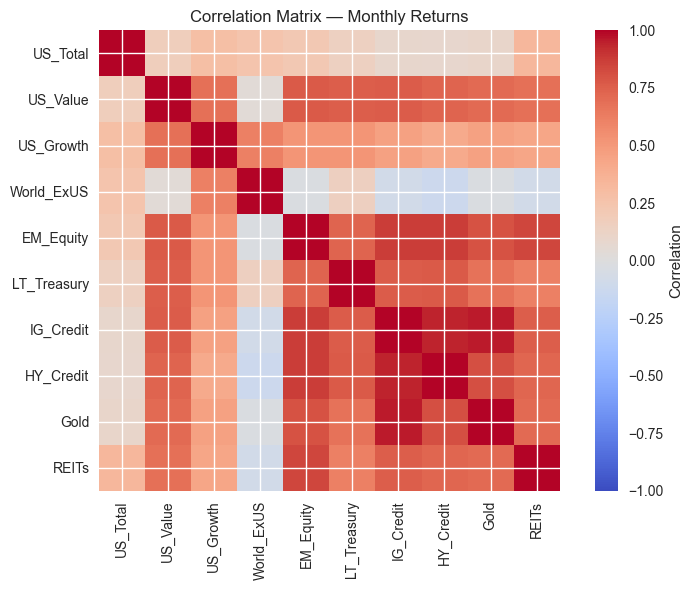

In [7]:
#Cell 10 — Correlation Heatmap

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
fig.colorbar(cax, ax=ax, label="Correlation")
ax.set_title("Correlation Matrix — Monthly Returns")
plt.tight_layout()
plt.show()


## 3. Ray Dalio “All Weather” Portfolio (Approximation)

We approximate the All‑Weather allocation:

- 30% equities (US + World + EM)
- 40% long‑term Treasuries
- 15% credit (IG + HY)
- 7.5% gold
- 7.5% REITs


In [8]:
# Cell 12 — All Weather Weights
all_weather_weights = pd.Series(0.0, index=returns.columns)

all_weather_weights["US_Total"] = 0.15
all_weather_weights["World_ExUS"] = 0.10
all_weather_weights["EM_Equity"] = 0.05

all_weather_weights["LT_Treasury"] = 0.40

all_weather_weights["IG_Credit"] = 0.10
all_weather_weights["HY_Credit"] = 0.05

all_weather_weights["Gold"] = 0.075
all_weather_weights["REITs"] = 0.075

all_weather_weights


US_Total       0.150
US_Value       0.000
US_Growth      0.000
World_ExUS     0.100
EM_Equity      0.050
LT_Treasury    0.400
IG_Credit      0.100
HY_Credit      0.050
Gold           0.075
REITs          0.075
dtype: float64

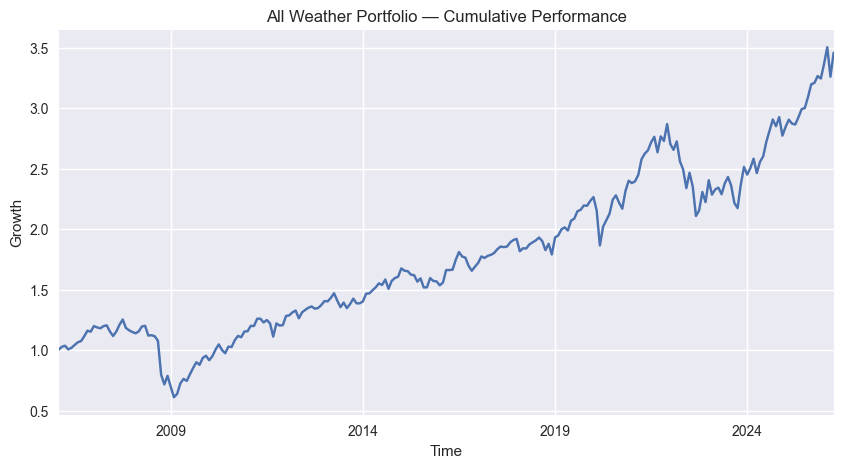

All Weather — Annualized Return: 0.073
All Weather — Annualized Volatility: 0.146
All Weather — Sharpe Ratio: 0.496


In [9]:
# Cell 13 — All Weather Backtest
aw_ret, aw_cum = backtest_portfolio(returns, all_weather_weights.values)

plot_performance(aw_cum, "All Weather Portfolio — Cumulative Performance")

aw_ann_ret = annualized_return(aw_ret)
aw_ann_vol = annualized_volatility(aw_ret)
aw_sharpe = aw_ann_ret / aw_ann_vol

print("All Weather — Annualized Return:", round(aw_ann_ret, 3))
print("All Weather — Annualized Volatility:", round(aw_ann_vol, 3))
print("All Weather — Sharpe Ratio:", round(aw_sharpe, 3))


## 4. Maximum Sharpe Ratio Portfolio Optimization


In [10]:
# Cell 15 — Optimize Sharpe
opt_weights = maximize_sharpe(returns)
opt_weights_series = pd.Series(opt_weights, index=returns.columns)
opt_weights_series


US_Total       3.773285e-01
US_Value       0.000000e+00
US_Growth      0.000000e+00
World_ExUS     1.105920e-01
EM_Equity      2.490710e-16
LT_Treasury    1.265841e-16
IG_Credit      2.314386e-16
HY_Credit      5.781290e-02
Gold           4.542666e-01
REITs          0.000000e+00
dtype: float64

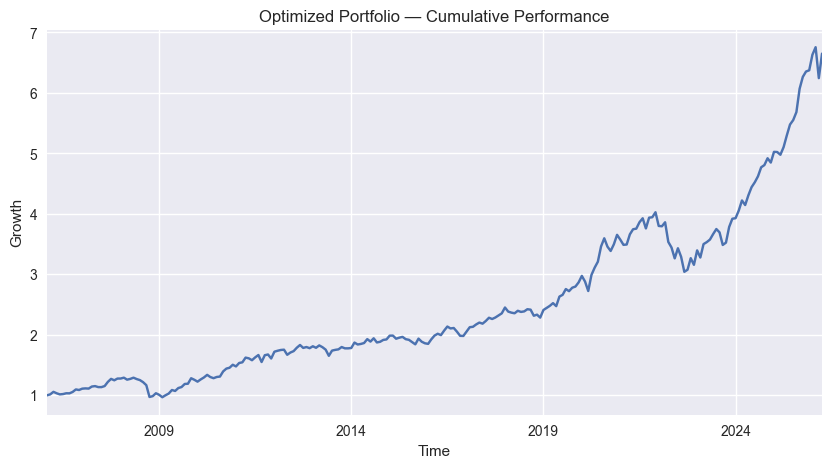

Optimized — Annualized Return: 0.1
Optimized — Annualized Volatility: 0.114
Optimized — Sharpe Ratio: 0.88


In [11]:
# Cell 16 — Optimized Portfolio Backtest
opt_ret, opt_cum = backtest_portfolio(returns, opt_weights)

plot_performance(opt_cum, "Optimized Portfolio — Cumulative Performance")

opt_ann_ret = annualized_return(opt_ret)
opt_ann_vol = annualized_volatility(opt_ret)
opt_sharpe = opt_ann_ret / opt_ann_vol

print("Optimized — Annualized Return:", round(opt_ann_ret, 3))
print("Optimized — Annualized Volatility:", round(opt_ann_vol, 3))
print("Optimized — Sharpe Ratio:", round(opt_sharpe, 3))


In [12]:
# Cell 17 — Comparison AW vs Optimized
comparison = pd.DataFrame({
    "Annualized_Return": [aw_ann_ret, opt_ann_ret],
    "Annualized_Volatility": [aw_ann_vol, opt_ann_vol],
    "Sharpe": [aw_sharpe, opt_sharpe],
}, index=["All_Weather", "Optimized"])

comparison


,Annualized_Return,Annualized_Volatility,Sharpe
All_Weather,0.072503,0.146113,0.496215
Optimized,0.100489,0.114252,0.879540


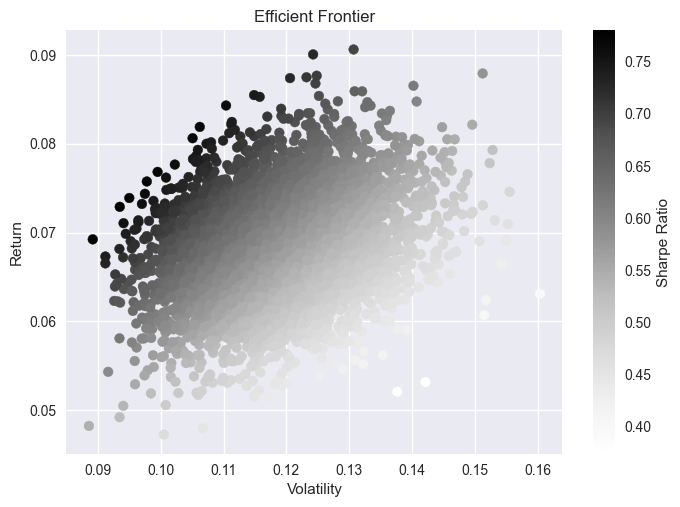

In [13]:
# Cell 18 — Efficient Frontier
ef = generate_random_portfolios(returns, n_portfolios=5000)
plot_efficient_frontier(ef)


## 5. Rolling Window Backtest (Dynamic Re‑Optimization)

We simulate a realistic investor who:

- Uses a 36‑month rolling window
- Re‑optimizes weights each month
- Applies weights to the next month’s returns


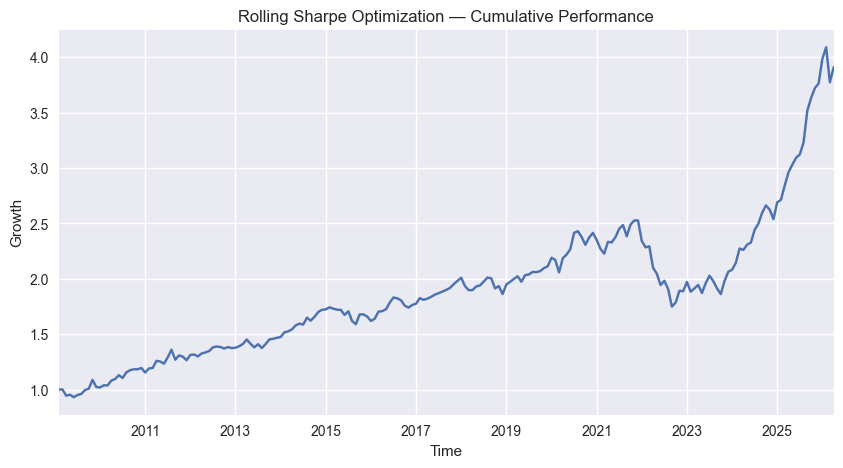

Rolling — Annualized Return: 0.085
Rolling — Annualized Volatility: 0.103
Rolling — Sharpe Ratio: 0.823


In [14]:
# Cell 20 — Rolling Backtest
rb_ret, rb_cum = rolling_backtest(returns, window=36)

plot_performance(rb_cum, "Rolling Sharpe Optimization — Cumulative Performance")

rb_ann_ret = annualized_return(rb_ret)
rb_ann_vol = annualized_volatility(rb_ret)
rb_sharpe = rb_ann_ret / rb_ann_vol

print("Rolling — Annualized Return:", round(rb_ann_ret, 3))
print("Rolling — Annualized Volatility:", round(rb_ann_vol, 3))
print("Rolling — Sharpe Ratio:", round(rb_sharpe, 3))


## 6. Cross‑Sectional Momentum Strategy

- Rank ETFs by past 12‑month performance
- Select top 3
- Allocate equal weights
- Rebalance monthly


In [15]:
#Cell 22 — Momentum Weights
weights_mom = momentum_strategy(returns, lookback=12, top_n=3)
weights_mom.tail()


c:\Finance\Quant-projects\Quant_projects\ETF_Portfolio_optimization\src\momentum.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.3333333333333333' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  weights.loc[date, top_assets] = 1 / top_n
c:\Finance\Quant-projects\Quant_projects\ETF_Portfolio_optimization\src\momentum.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.3333333333333333' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  weights.loc[date, top_assets] = 1 / top_n
c:\Finance\Quant-projects\Quant_projects\ETF_Portfolio_optimization\src\momentum.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.3333333333333333' has dtype incompatible with

,US_Total,US_Value,US_Growth,World_ExUS,EM_Equity,LT_Treasury,IG_Credit,HY_Credit,Gold,REITs
Date,,,,,,,,,,
2025-12-31,0.333333,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.333333
2026-01-31,0.333333,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.333333
2026-02-28,0.333333,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.333333
2026-03-31,0.333333,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.333333
2026-04-30,0.333333,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.333333


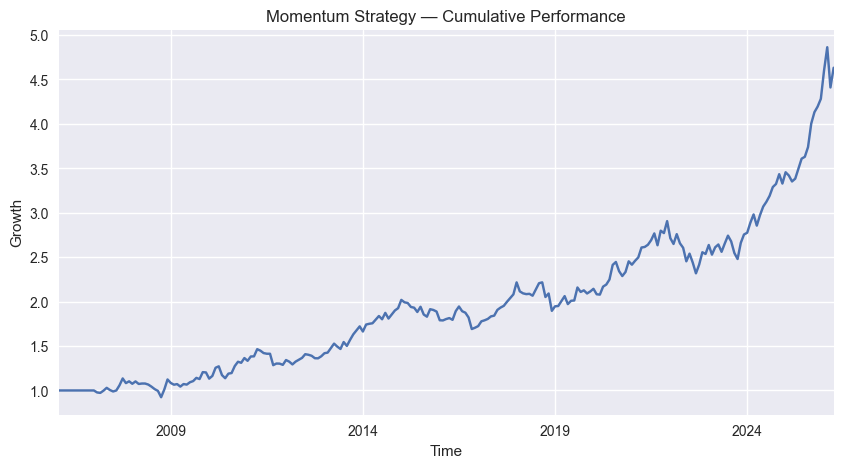

Momentum — Annualized Return: 0.083
Momentum — Annualized Volatility: 0.118
Momentum — Sharpe Ratio: 0.7


In [16]:
# Cell 23 — Momentum Backtest

mom_ret = apply_strategy(returns, weights_mom)
mom_cum = (1 + mom_ret).cumprod()

plot_performance(mom_cum, "Momentum Strategy — Cumulative Performance")

mom_ann_ret = annualized_return(mom_ret)
mom_ann_vol = annualized_volatility(mom_ret)
mom_sharpe = mom_ann_ret / mom_ann_vol

print("Momentum — Annualized Return:", round(mom_ann_ret, 3))
print("Momentum — Annualized Volatility:", round(mom_ann_vol, 3))
print("Momentum — Sharpe Ratio:", round(mom_sharpe, 3))


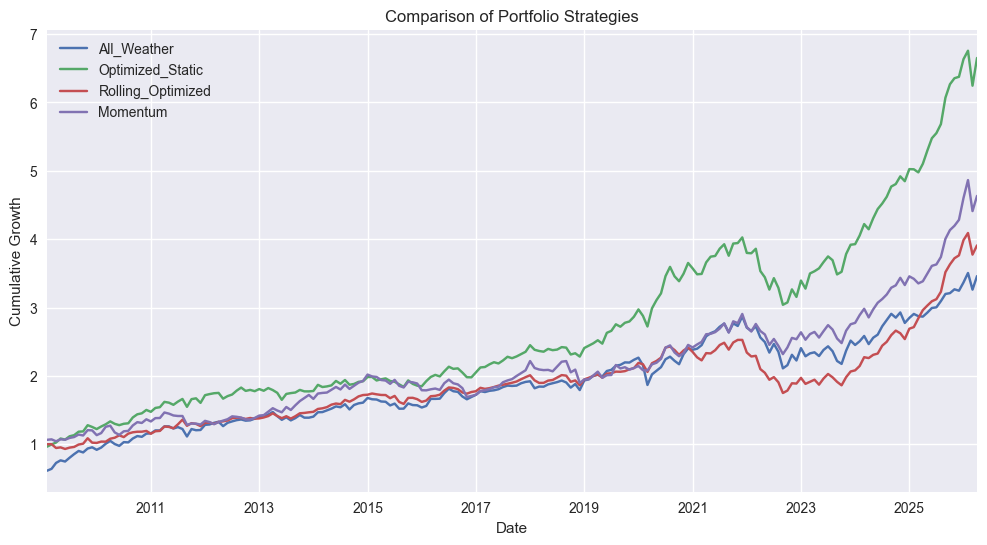

In [17]:
# Cell 24 — Global Comparison
cum_all = pd.DataFrame({
    "All_Weather": aw_cum,
    "Optimized_Static": opt_cum,
    "Rolling_Optimized": rb_cum,
    "Momentum": mom_cum,
}).dropna()

cum_all.plot(figsize=(12, 6), title="Comparison of Portfolio Strategies")
plt.ylabel("Cumulative Growth")
plt.show()


In [18]:
# Cell 25 — Metrics Comparison Table
metrics_all = pd.DataFrame({
    "Annualized_Return": [
        aw_ann_ret, opt_ann_ret, rb_ann_ret, mom_ann_ret
    ],
    "Annualized_Volatility": [
        aw_ann_vol, opt_ann_vol, rb_ann_vol, mom_ann_vol
    ],
    "Sharpe": [
        aw_sharpe, opt_sharpe, rb_sharpe, mom_sharpe
    ],
}, index=["All_Weather", "Optimized_Static", "Rolling_Optimized", "Momentum"])

metrics_all


,Annualized_Return,Annualized_Volatility,Sharpe
All_Weather,0.072503,0.146113,0.496215
Optimized_Static,0.100489,0.114252,0.879540
Rolling_Optimized,0.084539,0.102677,0.823348
Momentum,0.082921,0.118409,0.700293


In [19]:
# Cell 26 — Sensitivity Analysis
sens = sensitivity_analysis(returns, opt_weights, shock=0.05)
sens


,Asset,Return_up,Return_down
0,0,0.100493,0.100484
1,1,0.097872,0.103381
2,2,0.097665,0.103610
3,3,0.097119,0.104214
4,4,0.097879,0.103373
5,5,0.098630,0.102543
6,6,0.100581,0.100387
7,7,0.099871,0.101172
8,8,0.101385,0.099499
9,9,0.098251,0.102963


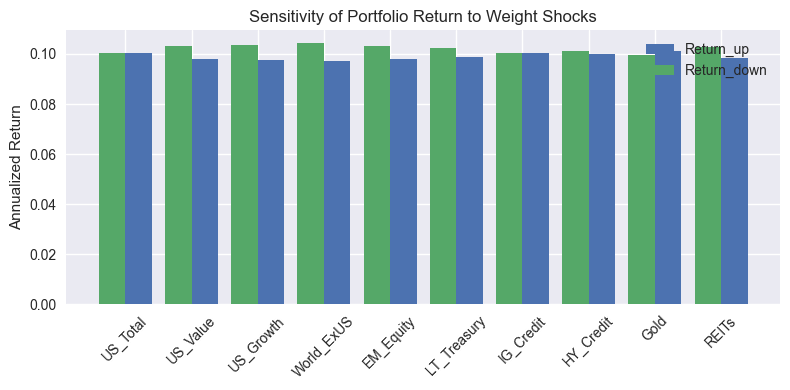

In [20]:
# Cell 27 — Sensitivity Plot
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(sens))
ax.bar(x, sens["Return_up"], width=0.4, label="Return_up", align="edge")
ax.bar(x, sens["Return_down"], width=-0.4, label="Return_down", align="edge")
ax.set_xticks(x)
ax.set_xticklabels(returns.columns, rotation=45)
ax.set_ylabel("Annualized Return")
ax.set_title("Sensitivity of Portfolio Return to Weight Shocks")
ax.legend()
plt.tight_layout()
plt.show()


# Conclusion

This notebook demonstrates a complete ETF portfolio research workflow:

- Multi‑asset ETF universe
- Monthly returns, descriptive statistics, correlations
- All‑Weather portfolio construction and backtest
- Maximum Sharpe Ratio optimization
- Efficient Frontier simulation
- Rolling window dynamic allocation
- Cross‑sectional momentum strategy
- Sensitivity analysis of portfolio weights
- Full performance comparison

This framework reflects realistic quantitative portfolio management practices and can be extended with:

- Transaction costs
- Regime‑based allocation
- Risk parity
- Minimum variance optimization
- Factor models
- Benchmark comparison (e.g., MSCI World)

This notebook is suitable for professional presentation in a quantitative finance context.
